In [1]:
import pandas as pd

df = pd.read_csv("results_opg7.csv")
df

,index,raw_value,sorted_value,exact,mse,count_sketch_ms,exact_f2_ms,counter_bitwidth
0,1,11190940,11172924,11184812,31314133.76,948698.3931,13642.4637,23
1,2,11176508,11173660,11184812,31314133.76,948698.3931,13642.4637,23
2,3,11182676,11174220,11184812,31314133.76,948698.3931,13642.4637,23
3,4,11180388,11174316,11184812,31314133.76,948698.3931,13642.4637,23
4,5,11196548,11174852,11184812,31314133.76,948698.3931,13642.4637,23
...,...,...,...,...,...,...,...,...
95,96,11172924,11193468,11184812,31314133.76,948698.3931,13642.4637,23
96,97,11183668,11195436,11184812,31314133.76,948698.3931,13642.4637,23
97,98,11183836,11196548,11184812,31314133.76,948698.3931,13642.4637,23
98,99,11191884,11199076,11184812,31314133.76,948698.3931,13642.4637,23


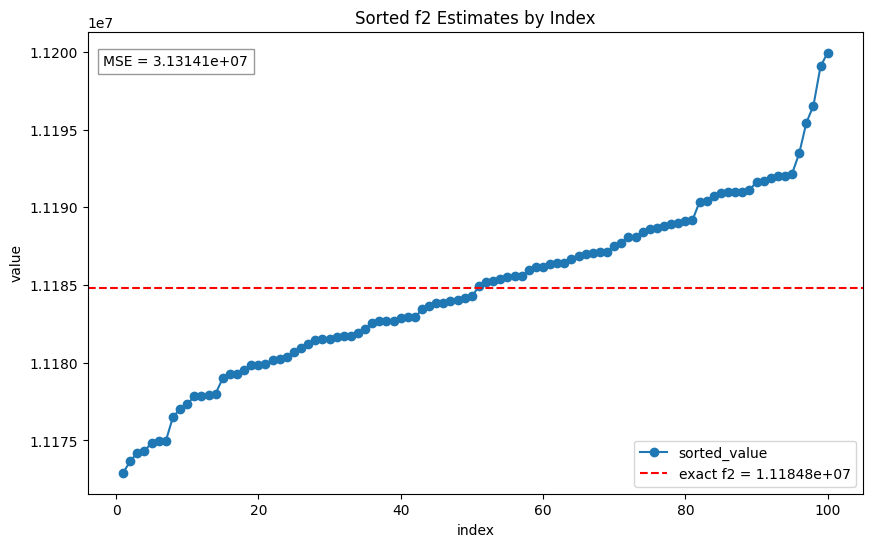

In [3]:
import matplotlib.pyplot as plt

exact_f2_value = df['exact'].iloc[0]
mse_value = df['mse'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(df['index'], df['sorted_value'], marker='o', linestyle='-', label='sorted_value')
plt.axhline(y=exact_f2_value, color='r', linestyle='--', label=f'exact f2 = {exact_f2_value:.6g}')
plt.title('Sorted f2 Estimates by Index')
plt.gca().text(0.02, 0.95, f'MSE = {mse_value:.6g}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.xlabel('index')
plt.ylabel('value')
plt.legend()
sorted_f2_ylim = plt.gca().get_ylim()
plt.show()

Vi beregner gennemsnittet for vores estimater og sammenligner med den eksakte F2-værdi,

In [4]:
mean_estimate = df["raw_value"].mean().item()

print(f"Mean of raw_value: {mean_estimate:.6g}")
print(f"Exact f2 value: {exact_f2_value:.6g}")

percentage_error = abs(mean_estimate - exact_f2_value) / exact_f2_value * 100
print(f"Error (|mean - exact|): {abs(mean_estimate - exact_f2_value):.6g} ({percentage_error:.6f}%)")

Mean of raw_value: 1.11847e+07
Exact f2 value: 1.11848e+07
Error (|mean - exact|): 128.16 (0.001146%)


In [6]:
l = df['counter_bitwidth'].iloc[0]
num_buckets = 1 << l
exp_variance = 2*exact_f2_value**2 / num_buckets
print(f"Expected variance of the estimator: {exp_variance:.6g}")
print(f"Empirical variance of the estimator: {mse_value:.6g}")
print(f"Error (|empirical variance - expected variance|): {abs(mse_value - exp_variance):.6g} ({abs(mse_value - exp_variance) / exp_variance * 100:.6f}%)")

Expected variance of the estimator: 2.98262e+07
Empirical variance of the estimator: 3.13141e+07
Error (|empirical variance - expected variance|): 1.48796e+06 (4.988790%)


## Gruppering

In [7]:
# Split raw_value into groups of 11 elements
group_size = 11
num_groups = 9
raw_values = df['raw_value'].values
groups = {f'G_{i+1}': raw_values[i*group_size:(i+1)*group_size] for i in range(num_groups)}
groups

{'G_1': array([11190940, 11176508, 11182676, 11180388, 11196548, 11189124,
        11184276, 11174220, 11177924, 11177020, 11179004]),
 'G_2': array([11179868, 11186156, 11185188, 11195436, 11190404, 11182924,
        11192172, 11182588, 11189172, 11182700, 11188900]),
 'G_3': array([11185420, 11183428, 11181892, 11193468, 11185964, 11190988,
        11184004, 11191988, 11190980, 11186860, 11180676]),
 'G_4': array([11199076, 11184908, 11191092, 11179292, 11177892, 11188620,
        11184060, 11173660, 11187156, 11174948, 11177316]),
 'G_5': array([11190756, 11191668, 11177860, 11190996, 11182140, 11186140,
        11183844, 11182924, 11174316, 11186972, 11188780]),
 'G_6': array([11184196, 11185228, 11179260, 11179860, 11185492, 11180268,
        11188684, 11192028, 11181700, 11181668, 11186404]),
 'G_7': array([11181516, 11181460, 11180204, 11190356, 11188996, 11181516,
        11179924, 11180932, 11174964, 11187732, 11188060]),
 'G_8': array([11199948, 11181740, 11182908, 11186396, 

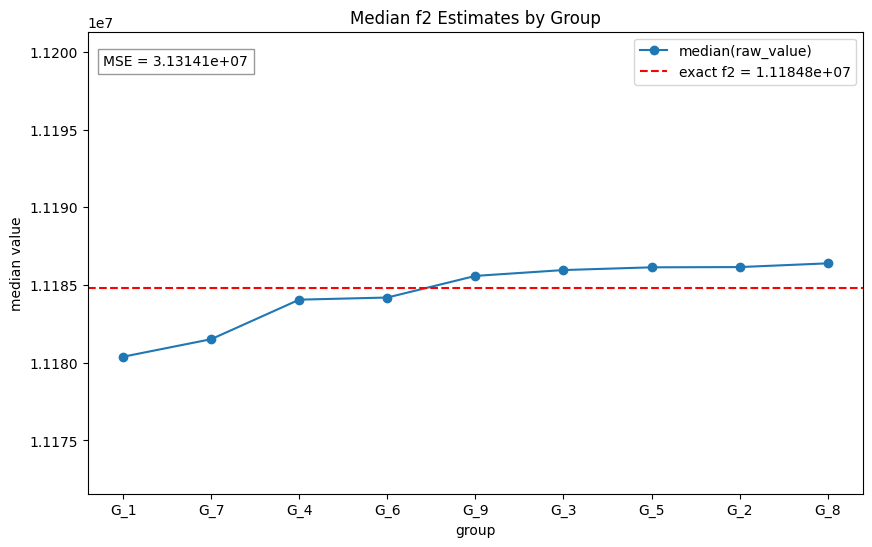

In [8]:
group_size = globals().get('group_size', 11)
raw_values = df['raw_value'].values
num_groups = len(raw_values) // group_size
kvps = {f"G_{i+1}": pd.Series(raw_values[i*group_size:(i+1)*group_size]).median() for i in range(num_groups)}
kvps = {k:v for k,v in sorted(kvps.items(), key=lambda item: item[1])}
group_labels = list(kvps.keys())
medians = list(kvps.values())

exact_f2_value = df['exact'].iloc[0]
mse_value = df['mse'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(group_labels, medians, marker='o', linestyle='-', label='median(raw_value)')
plt.axhline(y=exact_f2_value, color='r', linestyle='--', label=f'exact f2 = {exact_f2_value:.6g}')
plt.title('Median f2 Estimates by Group')
plt.ylim(globals().get('sorted_f2_ylim', plt.gca().get_ylim()))
plt.gca().text(0.02, 0.95, f'MSE = {mse_value:.6g}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.xlabel('group')
plt.ylabel('median value')
plt.legend()
plt.show()


Vi kan se at variansen af disse medianværdier,

In [9]:
import numpy as np
np.array(medians).var(ddof=0)

np.float64(4272398.222222222)

er markant lavere end variansen for alle estimater,

In [10]:
mse_value

np.float64(31314133.76)